In [1]:
!pip install gcsfs pyarrow   # for GCS parquet upload. running in terminal

In [2]:
import pandas as pd

path = "gs://emotor-dataset-raw/current_temp_short/0Nm_BPFI_30.parquet"

df = pd.read_parquet(path)

print(df.shape)
df.head()

(1536492, 5)


,Log/cDAQ9185-1F486B5Mod1/ai0,Log/cDAQ9185-1F486B5Mod1/ai1,Log/cDAQ9185-1F486B5Mod2/ai0,Log/cDAQ9185-1F486B5Mod2/ai2,Log/cDAQ9185-1F486B5Mod2/ai3
0,26.947089,26.958406,2.403172,0.839570,-2.330803
1,26.947089,26.958406,2.091861,0.886275,-2.284899
2,26.947089,26.958406,2.127518,0.651380,-2.117976
3,26.947089,26.958406,2.286602,0.544234,-2.172226
4,26.947089,26.958406,2.551285,0.538740,-2.371143


In [3]:
mod1_cols = [c for c in df.columns if "cDAQ9185" in c and "Mod1" in c]
mod2_cols = [c for c in df.columns if "cDAQ9185" in c and "Mod2" in c]

mod1_cols, mod2_cols

(['Log/cDAQ9185-1F486B5Mod1/ai0', 'Log/cDAQ9185-1F486B5Mod1/ai1'],
 ['Log/cDAQ9185-1F486B5Mod2/ai0',
  'Log/cDAQ9185-1F486B5Mod2/ai2',
  'Log/cDAQ9185-1F486B5Mod2/ai3'])

/tmp/ipykernel_45473/111809719.py:33: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/jhord/.pyenv/versions/emotor_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


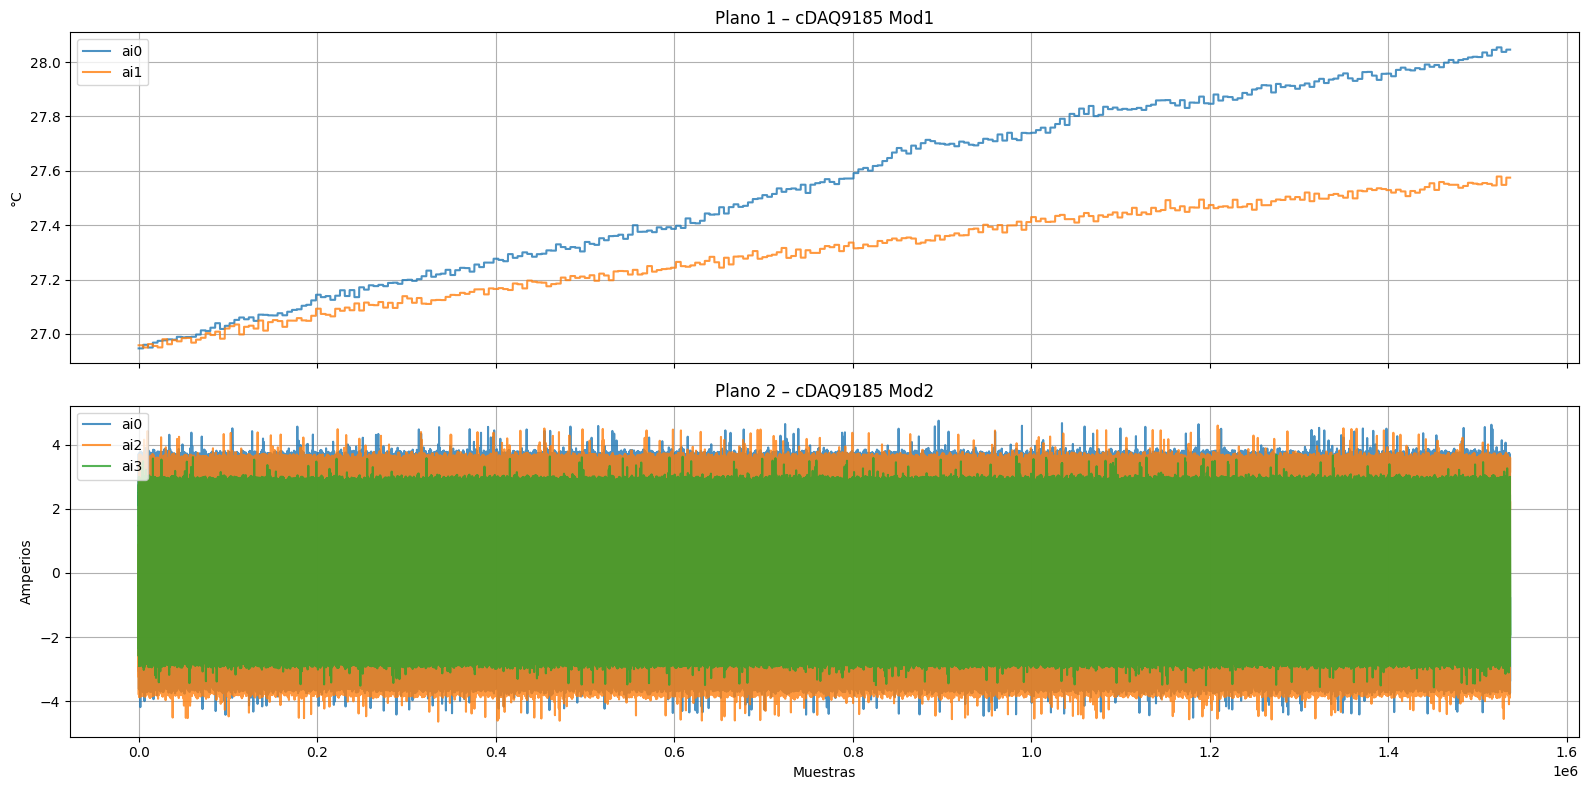

In [4]:
import matplotlib.pyplot as plt

# Reducimos puntos para visualización (opcional pero recomendado)
N = 2_000_000
df_plot = df.iloc[:N]

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(16, 8),
    sharex=True
)

# -------- Plano Mod1 --------
for col in mod1_cols:
    axes[0].plot(df_plot[col], label=col.split("/")[-1], alpha=0.8)

axes[0].set_title("Plano 1 – cDAQ9185 Mod1")
axes[0].set_ylabel("°C")
axes[0].legend()
axes[0].grid(True)

# -------- Plano Mod2 --------
for col in mod2_cols:
    axes[1].plot(df_plot[col], label=col.split("/")[-1], alpha=0.8)

axes[1].set_title("Plano 2 – cDAQ9185 Mod2")
axes[1].set_xlabel("Muestras")
axes[1].set_ylabel("Amperios")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [5]:
import numpy as np

df = df.copy()

signals = {}

# extraemos corrientes
signals["current"] = df[mod2_cols]

# centrado (quitar componente DC) POR CANAL
signals["current_centered"] = signals["current"] - signals["current"].mean()

In [6]:
df.head()

,Log/cDAQ9185-1F486B5Mod1/ai0,Log/cDAQ9185-1F486B5Mod1/ai1,Log/cDAQ9185-1F486B5Mod2/ai0,Log/cDAQ9185-1F486B5Mod2/ai2,Log/cDAQ9185-1F486B5Mod2/ai3
0,26.947089,26.958406,2.403172,0.839570,-2.330803
1,26.947089,26.958406,2.091861,0.886275,-2.284899
2,26.947089,26.958406,2.127518,0.651380,-2.117976
3,26.947089,26.958406,2.286602,0.544234,-2.172226
4,26.947089,26.958406,2.551285,0.538740,-2.371143


In [7]:
fs = 25600 # Hz, Watch out! Freq getting in tdms_mat_utils.ipynb

# FFT returning frequencies and magnitudes
def compute_fft(signal, fs):
    n = len(signal)
    freqs = np.fft.rfftfreq(n, d=1/fs)
    fft_vals = np.fft.rfft(signal)
    magnitude = np.abs(fft_vals) / n
    return freqs, magnitude

In [8]:
# FFT applied to centered current signals
fft_results = {}

for col in mod2_cols:
    sig = signals["current_centered"][col].values
    freqs, mag = compute_fft(sig, fs)
    fft_results[col] = (freqs, mag)

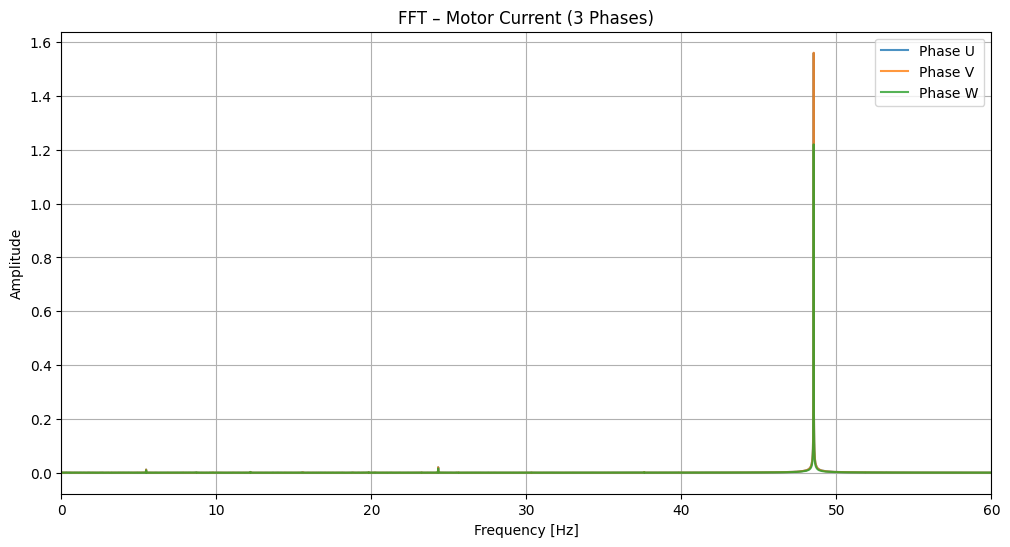

In [13]:
plt.figure(figsize=(12, 6))

for col, label in zip(
    mod2_cols,
    ["Phase U", "Phase V", "Phase W"]
):
    freqs, mag = fft_results[col]
    plt.plot(freqs, mag, label=label, alpha=0.8)

plt.xlim(0, 60)   # hasta 500 Hz (zona útil para diagnóstico)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.title("FFT – Motor Current (3 Phases)")
plt.legend()
plt.grid(True)
plt.show()

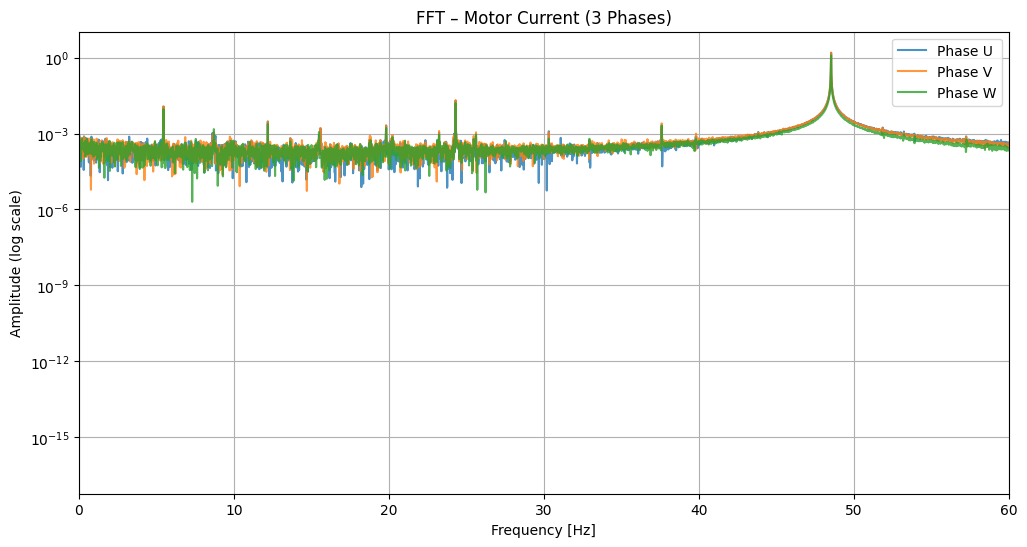

In [12]:
plt.figure(figsize=(12, 6))

for col, label in zip(
    mod2_cols,
    ["Phase U", "Phase V", "Phase W"]
):
    freqs, mag = fft_results[col]
    plt.semilogy(freqs, mag, label=label, alpha=0.8)

plt.xlim(0, 60)   # evita 0 Hz en escala log
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude (log scale)")
plt.title("FFT – Motor Current (3 Phases)")
plt.legend()
plt.grid(True, which="both")
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_current_modules(
    path,
    title,
    n_samples=2_000_000
):
    # Leer parquet desde GCS
    df = pd.read_parquet(path)

    # Eliminar columnas totalmente NaN (por V8)
    df = df.dropna(axis=1, how="all")

    # Identificar canales por módulo
    mod1_cols = [c for c in df.columns if "cDAQ9185" in c and "Mod1" in c]
    mod2_cols = [c for c in df.columns if "cDAQ9185" in c and "Mod2" in c]

    # Submuestreo para visualización
    df_plot = df.iloc[:n_samples]

    # Crear figura
    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(16, 8),
        sharex=True
    )

    # -------- Mod1 --------
    for col in mod1_cols:
        axes[0].plot(df_plot[col], label=col.split("/")[-1], alpha=0.8)

    axes[0].set_title(f"{title} – cDAQ9185 Mod1")
    axes[0].set_ylabel("°C")
    axes[0].legend()
    axes[0].grid(True)

    # -------- Mod2 --------
    for col in mod2_cols:
        axes[1].plot(df_plot[col], label=col.split("/")[-1], alpha=0.8)

    axes[1].set_title(f"{title} – cDAQ9185 Mod2")
    axes[1].set_xlabel("Muestras")
    axes[1].set_ylabel("Amperios")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


In [ ]:
for label, path in paths.items():
    plot_current_modules(
        path=path,
        title=f"0Nm – {label}",
        n_samples=2_000_000
    )
